#### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Datos

In [2]:
df=pd.read_csv("data/car_fuel_efficiency.csv")
df.columns=df.columns.str.lower().str.replace(" ","_")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [33]:
cols=list(df.dtypes[df.dtypes=='object'].index)

for col in cols:
    df[col]=df[col].str.lower().str.replace(" ","_") #reemplazamos espacios por guiones bajos y pasamos a minusculas
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369


In [3]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [ ]:
variables=['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
df_red=df[variables]


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


Como se ve a continuación, la variable de la eficiencia del combustible tiene una distribución bastante asimétrica, es decir, no tiene marcada ni cola izquierda ni cola derecha

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

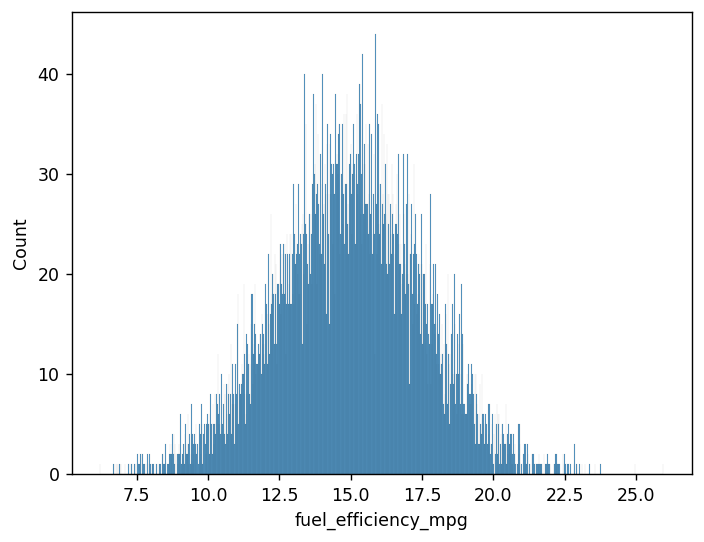

In [36]:
sns.histplot(df_red.fuel_efficiency_mpg, bins=1000)

##### Pregunta 1: hay una columna con valores nulos. ¿Cuál es?

#### Respuesta: la columna 'horsepower'

In [37]:
df_red.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

##### Pregunta 2: ¿Cuál es la mediana de la columna 'horsepower'?

##### Respuesta: $149.65729212983547$

In [38]:
df_red['horsepower'].mean()

np.float64(149.65729212983547)

##### Preparación y separación de los datos

In [39]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n,n_val+n_test+n_train 

(9704, 9704)

In [40]:
idx=np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
idx #indices aleatorios

array([ 483, 7506, 8795, ..., 5390,  860, 7270])

In [41]:
df_red_train=df_red.iloc[idx[:n_train]]
df_red_val=df_red.iloc[idx[n_train:n_train+n_val]]
df_red_test=df_red.iloc[idx[n_train+n_val:]] # uso idx para que los conjuntos de train, validation y test sean aleatorios

In [42]:
df_red_train=df_red_train.reset_index(drop=True)
df_red_val=df_red_val.reset_index(drop=True)
df_red_test=df_red_test.reset_index(drop=True)

In [43]:
y_train=df_red_train.fuel_efficiency_mpg.values # el .values sirve para haerlo como una matriz
y_val=df_red_val.fuel_efficiency_mpg.values
y_test=df_red_test.fuel_efficiency_mpg.values

In [44]:
del df_red_train['fuel_efficiency_mpg']
del df_red_val['fuel_efficiency_mpg']
del df_red_test['fuel_efficiency_mpg']

##### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 2 decimal digits using round(score, 2)
- Which option gives better RMSE?

In [14]:
Xs=['engine_displacement','horsepower','vehicle_weight','model_year']

In [10]:
def prepare_x_mean(df,df_train):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(df_train['horsepower'].mean())
    x=df_num.values
    return x

def prepare_x_zero(df):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(0)
    x=df_num.values
    return x

def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

def rmse(y,y_pred):
    error=y-y_pred
    se=error**2
    mse=se.mean()
    return round(np.sqrt(mse),2)

In [47]:
x_train_mean=prepare_x_mean(df_red_train,df_red_train)
w0_mean,w_mean=train_linear_regression(x_train_mean,y_train)
y_pred=w0_mean+x_train_mean.dot(w_mean)
rmse(y_train,y_pred)

np.float64(0.46)

In [48]:
x_train_zero=prepare_x_zero(df_red_train)
w0_zero,w_zero=train_linear_regression(x_train_zero,y_train)
y_pred=w0_zero+x_train_zero.dot(w_zero)
rmse(y_train,y_pred)

np.float64(0.52)

##### Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 2 decimal digits.
- Which r gives the best RMSE?

In [35]:
def train_linear_regression_reg(X,y,r=0.001):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0]) # shape[0] devuelve el número de filas de la matriz XTX, que es el mismo que el número de columnas, ya que XTX es una matriz cuadrada. Por lo tanto, np.eye(XTX.shape[0]) crea una matriz identidad del mismo tamaño que XTX, y al multiplicarla por 0.01 se obtiene una matriz diagonal con 0.01 en la diagonal principal y 0 en el resto de los elementos. Al sumar esta matriz a XTX, se obtiene una nueva matriz que es más estable numéricamente y que permite calcular su inversa sin problemas.
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [28]:
for r in [0,0.01,0.1,1,5,10,100]:
    X_train=prepare_x_zero(df_red_train)
    w0,w=train_linear_regression_reg(X_train,y_train,r=r)
    X_val=prepare_x_zero(df_red_val)
    y_pred=w0+X_val.dot(w)
    print(f"r={r}, RMSE={rmse(y_val,y_pred)}")

NameError: name 'df_red_train' is not defined

##### Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [25]:
rmse_scores = [] 

for seed in [0,1,2,3,4,5,6,7,8,9]:
    np.random.seed(seed)
    n = len(df_red)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df_red.iloc[idx[:n_train]]
    df_val = df_red.iloc[idx[n_train:n_train+n_val]]
    df_test = df_red.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True) 
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    X_train = prepare_x_zero(df_train)
    w0_zero, w_zero = train_linear_regression(X_train, y_train)
    
    X_val = prepare_x_zero(df_val)
    y_pred = w0_zero + X_val.dot(w_zero)
    
    # 2. Calculas el score para esta semilla
    score = rmse(y_val, y_pred)
    print(f"Seed {seed} -> RMSE={score}")
    
    # 3. Lo agregas a tu lista
    rmse_scores.append(score)

# 4. Fuera del bucle, calculas la desviación estándar y redondeas
std = np.std(rmse_scores)
print(f"\nDesviación estándar de los RMSE: {round(std, 3)}")

Seed 0 -> RMSE=0.52
Seed 1 -> RMSE=0.52
Seed 2 -> RMSE=0.52
Seed 3 -> RMSE=0.52
Seed 4 -> RMSE=0.51
Seed 5 -> RMSE=0.53
Seed 6 -> RMSE=0.53
Seed 7 -> RMSE=0.51
Seed 8 -> RMSE=0.51
Seed 9 -> RMSE=0.51

Desviación estándar de los RMSE: 0.007


##### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [36]:
np.random.seed(9)
n = len(df_red)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
 
idx = np.arange(n)
np.random.shuffle(idx)
 
df_train_val = df_red.iloc[idx[:n_train+n_val]]
df_test = df_red.iloc[idx[n_train+n_val:]]
    
df_train_val = df_train_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train_val = df_train_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_train_val = prepare_x_zero(df_train_val)
w0_zero, w_zero = train_linear_regression_reg(X_train_val, y_train_val,r=0.001)
    
X_test = prepare_x_zero(df_test)
y_pred = w0_zero + X_test.dot(w_zero)
    
# 2. Calculas el score para esta semilla
score = rmse(y_test, y_pred)
round(score,3)

np.float64(0.52)